In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

In [ ]:
# Standard library imports
import sys
from pathlib import Path

# Third-party scientific computing
import pandas as pd

# Deep learning frameworks

# Visualization

# Machine learning
from sklearn.pipeline import Pipeline

# Local imports - data processing
from src.data_models.caravanify import Caravanify, CaravanifyConfig
from src.data_models.datamodule import HydroDataModule
from src.preprocessing.grouped import GroupedTransformer
from src.preprocessing.standard_scale import StandardScaleTransformer
from src.preprocessing.log_scale import LogTransformer

# Local imports - models and evaluation
from src.models.dummy import RepeatLastValuesConfig, LitRepeatLastValues

from src.models.tft import TFTConfig, LitTFT
from src.models.ealstm import EALSTMConfig, LitEALSTM
from src.models.tide import TiDEConfig, LitTiDE
from src.models.tsmixer import TSMixerConfig, LitTSMixer
from src.model_evaluation.evaluators import TSForecastEvaluator
from src.model_evaluation.visualization import (
    # plot_metric_boxplot,
    # plot_rolling_forecast,
    plot_metric_cdf,
    plot_basin_map,
)
from src.model_evaluation.hp_from_yaml import hp_from_yaml

---

In [3]:
STATIC_FEATURES = [
    "gauge_id",
    "p_mean",
    "area",
    "ele_mt_sav",
    "high_prec_dur",
    "frac_snow",
    "high_prec_freq",
    "slp_dg_sav",
    "cly_pc_sav",
    "aridity_ERA5_LAND",
    "aridity_FAO_PM",
]

FORCING_FEATURES = [
    "snow_depth_water_equivalent_mean",
    "surface_net_solar_radiation_mean",
    "surface_net_thermal_radiation_mean",
    "potential_evaporation_sum_ERA5_LAND",
    "potential_evaporation_sum_FAO_PENMAN_MONTEITH",
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "total_precipitation_sum",
]

TARGET = "streamflow"

In [4]:
ealstm_yaml = "/Users/cooper/Desktop/CAMELS-CH/experiments/DataSharing/yaml_files/tajikistan/ealstm.yaml"
tft_yaml = "/Users/cooper/Desktop/CAMELS-CH/experiments/DataSharing/yaml_files/tajikistan/tft.yaml"
tide_yaml = "/Users/cooper/Desktop/CAMELS-CH/experiments/DataSharing/yaml_files/tajikistan/tide.yaml"
tsmixer_yaml = "/Users/cooper/Desktop/CAMELS-CH/experiments/DataSharing/yaml_files/tajikistan/tsmixer.yaml"

tft_hp = hp_from_yaml("tft", tft_yaml)
tide_hp = hp_from_yaml("tide", tide_yaml)
ealstm_hp = hp_from_yaml("ealstm", ealstm_yaml)
tsmixer_hp = hp_from_yaml("tsmixer", tsmixer_yaml)

In [5]:
TFT_config = TFTConfig(**tft_hp)
EALSTM_config = EALSTMConfig(**ealstm_hp)
TiDE_config = TiDEConfig(**tide_hp)
TSMixer_config = TSMixerConfig(**tsmixer_hp)

dummy_config = RepeatLastValuesConfig(
    input_len=tide_hp["input_len"],
    input_size=tide_hp["input_size"],
    output_len=tide_hp["output_len"],
)

---

In [6]:
# Either Kyrgyzstan or Tajikistan or combined
COUNTRY = "Tajikistan"

In [7]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    # human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

ca_caravan = Caravanify(config)
ca_basins = ca_caravan.get_all_gauge_ids()
# ca_basins = [bid for bid in ca_basins if bid not in ["CA_17110", "CA_17329"]]

print(f"Found {len(ca_basins)} total CA basins")

ca_caravan.load_stations(ca_basins)

# Prepare data frames
ts_columns = FORCING_FEATURES + [TARGET]
static_columns = STATIC_FEATURES

ca_ts_data = ca_caravan.get_time_series()[ts_columns + ["date"] + ["gauge_id"]]
ca_static_data = ca_caravan.get_static_attributes()[static_columns + ["country"]]

Found 78 total CA basins


In [8]:
# ids for the COUUNTRY

country_ids = ca_static_data[ca_static_data["country"] == COUNTRY]["gauge_id"].unique()

ca_ts_data = ca_ts_data[ca_ts_data["gauge_id"].isin(country_ids)]
ca_static_data = ca_static_data[ca_static_data["gauge_id"].isin(country_ids)]

print(f"Found {len(country_ids)} total CA basins in {COUNTRY}")

Found 16 total CA basins in Tajikistan


---

In [9]:
# Use GroupedTransformer for both features and target
feature_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

target_pipeline = GroupedTransformer(
    Pipeline([("log", LogTransformer()), ("scaler", StandardScaleTransformer())]),
    columns=[TARGET],
    group_identifier="gauge_id",
    n_jobs=-1,
)


static_pipeline = Pipeline([("scaler", StandardScaleTransformer())])
preprocessing_config = {
    "features": {"pipeline": feature_pipeline},
    "target": {"pipeline": target_pipeline},
    "static_features": {"pipeline": static_pipeline},
}

In [10]:
STATIC_FEATURES = [col for col in static_columns]
FORCING_FEATURES = FORCING_FEATURES + [TARGET]

tft_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tft_hp["input_len"],
    output_length=tft_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

ealstm_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=ealstm_hp["input_len"],
    output_length=ealstm_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

tide_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tide_hp["input_len"],
    output_length=tide_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

tsmixer_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tsmixer_hp["input_len"],
    output_length=tsmixer_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

In [11]:
tft_combined_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/DataSharing/checkpoints/tajikistan/tft/Tajikistan_tft_epoch=10_val_loss=0.0499.ckpt"
ealstm_combined_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/DataSharing/checkpoints/tajikistan/ealstm/Tajikistan_ealstm_epoch=07_val_loss=0.0496.ckpt"
tide_combined_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/DataSharing/checkpoints/tajikistan/tide/Tajikistan_tide_epoch=12_val_loss=0.0527.ckpt"
tsmixer_combined_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/DataSharing/checkpoints/tajikistan/tsmixer/Tajikistan_tsmixer_epoch=15_val_loss=0.0494.ckpt"

ealstm_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/ealstm/run_0/Tajikistan_ealstm_epoch=33_val_loss=0.0549.ckpt"
tide_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/tide/run_0/Tajikistan_tide_epoch=46_val_loss=0.0616.ckpt"
tsmixer_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/tsmixer/run_0/Tajikistan_tsmixer_epoch=60_val_loss=0.0571.ckpt"
tft_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/tft/run_0/Tajikistan_tft_epoch=48_val_loss=0.0527.ckpt"


In [ ]:
dummy_model = LitRepeatLastValues(config=dummy_config)
tft_combined = LitTFT.load_from_checkpoint(tft_combined_ckpt, config=TFT_config)
ealstm_combined = LitEALSTM.load_from_checkpoint(
    ealstm_combined_ckpt, config=EALSTM_config
)
tide_combined = LitTiDE.load_from_checkpoint(tide_combined_ckpt, config=TiDE_config)
tsmixer_combined = LitTSMixer.load_from_checkpoint(
    tsmixer_combined_ckpt, config=TSMixer_config
)

tft_benchmark = LitTFT.load_from_checkpoint(tft_benchmark_ckpt, config=TFT_config)
ealstm_benchmark = LitEALSTM.load_from_checkpoint(
    ealstm_benchmark_ckpt, config=EALSTM_config
)
tide_benchmark = LitTiDE.load_from_checkpoint(tide_benchmark_ckpt, config=TiDE_config)
tsmixer_benchmark = LitTSMixer.load_from_checkpoint(
    tsmixer_benchmark_ckpt, config=TSMixer_config
)

# Create a dictionary mapping model names to (model, datamodule) tuples
models_and_datamodules = {
    "dummy": (dummy_model, tide_data_module),
    "tft_combined": (tft_combined, tft_data_module),
    "ealstm_combined": (ealstm_combined, ealstm_data_module),
    "tide_combined": (tide_combined, tide_data_module),
    "tsmixer_combined": (tsmixer_combined, tsmixer_data_module),
    "tft_benchmark": (tft_benchmark, tft_data_module),
    "ealstm_benchmark": (ealstm_benchmark, ealstm_data_module),
    "tide_benchmark": (tide_benchmark, tide_data_module),
    "tsmixer_benchmark": (tsmixer_benchmark, tsmixer_data_module),
}


evaluator = TSForecastEvaluator(
    horizons=list(range(1, 11)),
    models_and_datamodules=models_and_datamodules,
    trainer_kwargs={"accelerator": "gpu", "devices": 1},
)

In [13]:
# Run evaluation
results = evaluator.test_models()

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing dummy...
Original basins: 16
Retained basins: 16
Domain CA (source): Created 25709 valid sequences from 16 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.08807288110256195
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(25709, 10), obs=(25709, 10), basin_ids=(25709,)


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.0570613257586956
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(25709, 10), obs=(25709, 10), basin_ids=(25709,)


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing tsmixer_benchmark...
Original basins: 16
Retained basins: 16
Domain CA (source): Created 25309 valid sequences from 16 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          0.055097442120313644
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(25309, 10), obs=(25309, 10), basin_ids=(25309,)


In [ ]:
def filter_growing_season(eval_results):
    """
    Filter evaluation results to include only data from the growing season (April to October).

    Args:
        eval_results: Dictionary containing evaluation results with a 'df' key

    Returns:
        Dictionary with filtered dataframe and original metrics
    """
    # Create a copy of the results to avoid modifying the original
    filtered_results = eval_results.copy()

    # Extract the dataframe
    df = eval_results["df"].copy()

    # Ensure date column is datetime
    df["date"] = pd.to_datetime(df["date"])

    # Filter for growing season (April to October)
    growing_season_df = df[(df["date"].dt.month >= 4) & (df["date"].dt.month < 10)]

    # Replace the dataframe in the results
    filtered_results["df"] = growing_season_df

    return filtered_results


seasonal_tide_combined_results = filter_growing_season(results["tide_combined"])
seasonal_tide_benchmark_results = filter_growing_season(results["tide_benchmark"])
seasonal_ealstm_combined_results = filter_growing_season(results["ealstm_combined"])
seasonal_ealstm_benchmark_results = filter_growing_season(results["ealstm_benchmark"])
seasonal_tsmixer_combined_results = filter_growing_season(results["tsmixer_combined"])
seasonal_tsmixer_benchmark_results = filter_growing_season(results["tsmixer_benchmark"])
seasonal_tft_combined_results = filter_growing_season(results["tft_combined"])
seasonal_tft_benchmark_results = filter_growing_season(results["tft_benchmark"])
seasonal_dummy_results = filter_growing_season(results["dummy"])


seasonal_tide_combined_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tide_combined_results["df"]
)
seasonal_tide_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tide_benchmark_results["df"]
)
seasonal_ealstm_combined_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_ealstm_combined_results["df"]
)
seasonal_ealstm_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_ealstm_benchmark_results["df"]
)
seasonal_tsmixer_combined_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tsmixer_combined_results["df"]
)
seasonal_tsmixer_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tsmixer_benchmark_results["df"]
)
seasonal_tft_combined_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tft_combined_results["df"]
)
seasonal_tft_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tft_benchmark_results["df"]
)
seasonal_dummy_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_dummy_results["df"]
)


seasonal_tide_combined_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tide_combined_results["df"]
)
seasonal_tide_benchmark_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tide_benchmark_results["df"]
)
seasonal_ealstm_combined_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_ealstm_combined_results["df"]
)
seasonal_ealstm_benchmark_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_ealstm_benchmark_results["df"]
)
seasonal_tsmixer_combined_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tsmixer_combined_results["df"]
)
seasonal_tsmixer_benchmark_results["basin_metrics"] = (
    evaluator._calculate_basin_metrics(seasonal_tsmixer_benchmark_results["df"])
)
seasonal_tft_combined_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tft_combined_results["df"]
)
seasonal_tft_benchmark_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tft_benchmark_results["df"]
)
seasonal_dummy_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_dummy_results["df"]
)

seasonal_results = {}

seasonal_results["tide_combined"] = seasonal_tide_combined_results
seasonal_results["tide_benchmark"] = seasonal_tide_benchmark_results
seasonal_results["ealstm_combined"] = seasonal_ealstm_combined_results
seasonal_results["ealstm_benchmark"] = seasonal_ealstm_benchmark_results
seasonal_results["tsmixer_combined"] = seasonal_tsmixer_combined_results
seasonal_results["tsmixer_benchmark"] = seasonal_tsmixer_benchmark_results
seasonal_results["tft_combined"] = seasonal_tft_combined_results
seasonal_results["tft_benchmark"] = seasonal_tft_benchmark_results
seasonal_results["dummy"] = seasonal_dummy_results

In [ ]:
from typing import List, Optional
import matplotlib.pyplot as plt
import seaborn as sns


def generate_color_pairs(
    num_pairs: int,
    base_palette: Optional[str] = "husl",
    lightness_factor: float = 0.5,
) -> List[str]:
    # Get base colors from seaborn
    base_colors = sns.color_palette(base_palette, n_colors=num_pairs // 2)

    # Create lighter versions of each color
    light_colors = []
    for rgb in base_colors:
        # Convert to brighter version by moving toward white
        light_rgb = tuple(c + (1 - c) * lightness_factor for c in rgb)
        light_colors.append(light_rgb)

    # Interleave dark and light variants to create pairs
    color_pairs = []
    for dark, light in zip(base_colors, light_colors):
        color_pairs.extend([dark, light])

    return color_pairs

In [16]:
sns.set_context("paper", font_scale=1.3)

In [254]:
from typing import Dict, List, Optional, Tuple, Union
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np
import seaborn as sns
from typing import List, Optional


def plot_metric_boxplot(
    evaluator_results: Dict[str, Dict],
    model_names: List[str],
    metric: str = "NSE",
    horizons: Optional[List[int]] = None,
    fig_size: Tuple[int, int] = (10, 6),
    title: Optional[str] = None,
    palette: Optional[Union[str, List[str]]] = None,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create a boxplot visualization of model performance metrics with a single combined legend.

    Args:
        evaluator_results: Dictionary containing evaluation results for each model
        model_names: List of model names to include in the plot
        metric: Performance metric to visualize (e.g., "NSE", "RMSE")
        horizons: Optional list of forecast horizons to include
        fig_size: Figure dimensions as (width, height)
        title: Custom plot title (auto-generated if None)
        palette: Color palette for the plot

    Returns:
        Figure and Axes objects of the created plot
    """
    # Validate inputs
    if not model_names:
        raise ValueError("At least one model name must be provided")

    missing_models = [model for model in model_names if model not in evaluator_results]
    if missing_models:
        raise ValueError(f"Models not found in evaluator results: {missing_models}")

    # Create a DataFrame for all models' data
    all_data = []

    for model_name in model_names:
        # Extract basin metrics for this model
        basin_metrics = evaluator_results[model_name]["basin_metrics"]

        # Flatten the nested dictionary to a DataFrame
        for basin, horizon_data in basin_metrics.items():
            for horizon, metrics_dict in horizon_data.items():
                if metric in metrics_dict:
                    all_data.append(
                        {
                            "model": model_name,
                            "basin_id": basin,
                            "horizon": horizon,
                            "metric_value": metrics_dict[metric],
                        }
                    )

    df = pd.DataFrame(all_data)

    # Filter by horizons if specified
    if horizons:
        df = df[df["horizon"].isin(horizons)]

    # Determine available horizons after filtering
    available_horizons = sorted(df["horizon"].unique())

    # Set up color palette
    if palette is None:
        # Default color palette based on number of models
        if len(model_names) == 1:
            palette = "Blues"
        else:
            # Use different color palettes for multiple models
            palette = sns.color_palette("husl", len(model_names))

    # Create figure
    fig, ax = plt.subplots(figsize=fig_size)

    # Create boxplot
    sns.boxplot(
        x="horizon", y="metric_value", hue="model", data=df, palette=palette, ax=ax
    )

    # Add median value labels for each model and horizon
    if len(model_names) <= 3:  # Only add labels if not too many models
        for h_idx, horizon in enumerate(available_horizons):
            for m_idx, model in enumerate(model_names):
                # Filter data for this horizon and model
                filtered = df[(df["horizon"] == horizon) & (df["model"] == model)]
                if not filtered.empty:
                    median = filtered["metric_value"].median()

                    # Calculate position for the text
                    model_count = len(model_names)
                    box_width = 0.8  # Default box width in seaborn
                    position = h_idx

                    # Calculate offset based on model index
                    if model_count > 1:
                        step = box_width / model_count
                        offset = step * (m_idx - (model_count - 1) / 2)
                        position += offset

                    ax.text(
                        position,
                        median + 0.02,
                        f"{median:.2f}",
                        ha="center",
                        va="bottom",
                        color="black",
                        fontweight="bold",
                        fontsize=8,
                    )

    # Set title and labels
    ax.set_xlabel("Forecast Horizon (days)")
    ax.set_ylabel(f"{metric} Value")

    if title:
        ax.set_title(title)

    # Create a single combined legend
    # First, get the handles and labels from the existing legend
    handles, labels = ax.get_legend_handles_labels()

    # Remove the existing legend
    ax.get_legend().remove()

    # Create new legend elements
    legend_elements = []

    # First, add the data type elements (black patches)
    legend_elements.extend(
        [
            Patch(facecolor="black", edgecolor="black", label="Benchmark", alpha=0.7),
            Patch(
                facecolor="black",
                edgecolor="black",
                label="With Kyrgyz data",
                alpha=0.4,
            ),
        ]
    )

    # Then add model elements with their respective colors
    # Extract unique model names (without _benchmark/_combined)
    unique_models = []
    model_colors = {}

    for model_name in labels:
        base_model = model_name.split("_")[0]  # Extract base model name
        if base_model not in unique_models:
            unique_models.append(base_model)
            # Find the first occurrence of this model to get its color
            model_idx = labels.index(model_name)
            model_colors[base_model] = handles[model_idx].get_facecolor()

    # Add model patches with their colors
    for model in unique_models:
        display_name = model.upper()
        legend_elements.append(
            Patch(
                facecolor=model_colors[model],
                edgecolor="black",
                label=display_name,
                alpha=0.8,
            )
        )

    # Create a single legend with all elements
    ax.legend(
        handles=legend_elements,
        loc="best",
        frameon=True,
        title=None,
        ncol=min(
            len(legend_elements), 3
        ),  # Adjust number of columns based on legend size
    )

    # Add grid lines for better readability
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")

    # Apply styling
    sns.despine()
    plt.tight_layout()

    return fig, ax

def plot_model_cdf_grid(
    seasonal_results: Dict, palette: List[str]
) -> Tuple[plt.Figure, List[plt.Axes]]:
    """
    Plot a grid of CDF curves for different models and prediction horizons with
    standardized x-axis limits per horizon.

    Args:
        seasonal_results: Dictionary containing model evaluation results by basin and horizon
        palette: List of colors to use for plotting benchmark and combined models

    Returns:
        Tuple containing the figure and list of axes
    """
    # Define models in the specified order and horizons
    models = ["tide", "ealstm", "tsmixer", "tft"]
    horizons = [1, 5, 10]

    # Define x-axis limits for each horizon row
    horizon_xlims = {
        1: (0.8, 1.0),  # 1-day horizon: 0.85 to 1.0
        5: (0.4, 1.0),  # 5-day horizon: 0.4 to 1.0
        10: (-0.2, 1.0),  # 10-day horizon: -0.2 to 1.0
    }

    # Create a mapping of model to color pairs
    color_map = {}
    for i, model in enumerate(models):
        # Each model gets a pair of colors (dark, light)
        color_map[model] = {
            "benchmark": palette[i * 2],  # Dark color for benchmark
            "combined": palette[i * 2 + 1],  # Light color for combined
        }

    # Create figure and subplots
    fig, axes = plt.subplots(3, 4, figsize=(10, 7))

    # Loop through each row (horizon)
    for i, horizon in enumerate(horizons):
        # Loop through each column (model)
        for j, model in enumerate(models):
            ax = axes[i, j]

            # Get benchmark and combined data
            benchmark_key = f"{model}_benchmark"
            combined_key = f"{model}_combined"

            # Extract NSE values for the specific horizon
            benchmark_nse = []
            combined_nse = []

            # Get benchmark values
            if benchmark_key in seasonal_results:
                for basin, metrics in seasonal_results[benchmark_key][
                    "basin_metrics"
                ].items():
                    if horizon in metrics and "NSE" in metrics[horizon]:
                        val = metrics[horizon]["NSE"]
                        # Convert numpy float32 to Python float if needed
                        if hasattr(val, "item"):
                            val = val.item()
                        # Only add non-NaN values
                        if not np.isnan(val):
                            benchmark_nse.append(val)

            # Get combined values
            if combined_key in seasonal_results:
                for basin, metrics in seasonal_results[combined_key][
                    "basin_metrics"
                ].items():
                    if horizon in metrics and "NSE" in metrics[horizon]:
                        val = metrics[horizon]["NSE"]
                        # Convert numpy float32 to Python float if needed
                        if hasattr(val, "item"):
                            val = val.item()
                        # Only add non-NaN values
                        if not np.isnan(val):
                            combined_nse.append(val)

            # Sort values for CDF
            benchmark_nse.sort()
            combined_nse.sort()

            # Calculate cumulative probabilities
            if benchmark_nse:
                benchmark_prob = np.arange(1, len(benchmark_nse) + 1) / len(
                    benchmark_nse
                )
                ax.plot(
                    benchmark_nse,
                    benchmark_prob,
                    label="Benchmark",
                    color=color_map[model]["benchmark"],
                    linewidth=1.8,
                )

                # Calculate and plot median for benchmark
                benchmark_median = np.median(benchmark_nse)
                ax.axvline(
                    x=benchmark_median,
                    color=color_map[model]["benchmark"],
                    linestyle="--",
                    linewidth=1.5,
                )

            if combined_nse:
                combined_prob = np.arange(1, len(combined_nse) + 1) / len(combined_nse)
                ax.plot(
                    combined_nse,
                    combined_prob,
                    label="Combined",
                    color=color_map[model]["combined"],
                    linewidth=1.8,
                )

                # Calculate and plot median for combined
                combined_median = np.median(combined_nse)
                ax.axvline(
                    x=combined_median,
                    color=color_map[model]["combined"],
                    linestyle="--",
                    linewidth=1.5,
                )

            # Set standardized x-axis limits based on horizon
            ax.set_xlim(horizon_xlims[horizon])

            # Ensure 1.0 is included in the x-ticks
            current_ticks = list(ax.get_xticks())
            if 1.0 not in current_ticks:
                current_ticks.append(1.0)
                ax.set_xticks(sorted(current_ticks))

            # Add titles and labels
            if i == 0:
                ax.set_title(model.upper(), fontsize=14)
            if j == 0:
                ax.set_ylabel(f"{horizon} Day - CDF", fontsize=12)
            if i == 2:
                ax.set_xlabel("NSE", fontsize=12)

            # Add grid and formatting
            ax.grid(True, alpha=0.3, linestyle="--")
            
            # Set y-axis to show values from 0 to 1 (not percentages)
            ax.set_ylim(0, 1)

    # Create a generic legend with solid and dashed lines
    handles = []
    handles.append(plt.Line2D([0], [0], color="black", linewidth=1.8))
    handles.append(plt.Line2D([0], [0], color="black", linewidth=1.8, alpha=0.5))
    handles.append(plt.Line2D([0], [0], color="black", linewidth=1.5, linestyle="--"))
    labels = ["Benchmark", "With Kyrgyz data", "Median value"]
    sns.despine()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, 0.01),
        fontsize=12,
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    return fig, axes


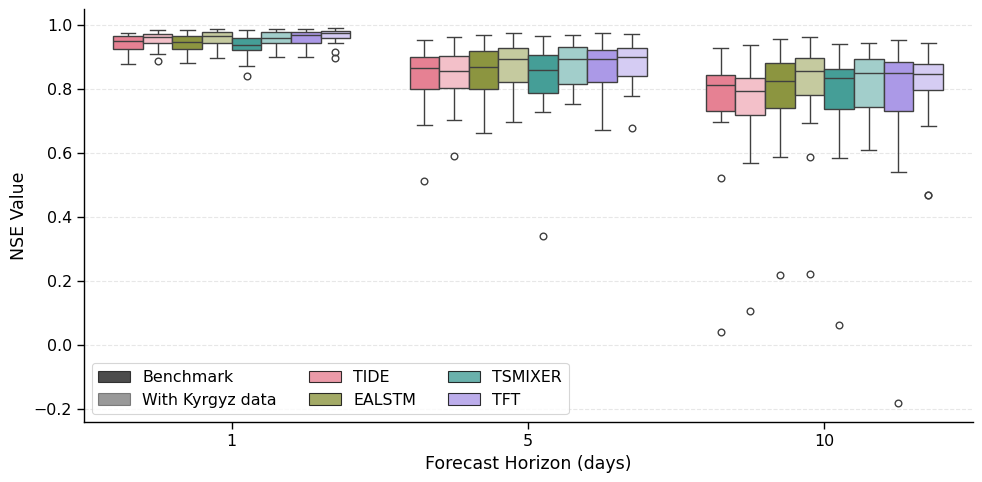

In [257]:
palette = generate_color_pairs(8)


fig, ax = plot_metric_boxplot(
    seasonal_results,
    [
        "tide_benchmark",
        "tide_combined",
        "ealstm_benchmark",
        "ealstm_combined",
        "tsmixer_benchmark",
        "tsmixer_combined",
        "tft_benchmark",
        "tft_combined",
    ],
    metric="NSE",
    palette=palette,
    horizons=[1, 5, 10],
    fig_size=(10, 5),
)

path_to_save = "/Users/cooper/Desktop/CAMELS-CH/images/DataSharing/regional_boxplots_all_models.png"
fig.savefig(path_to_save, dpi=300, bbox_inches="tight")
# # Set log scale for y-axis
# ax.set_yscale('log')

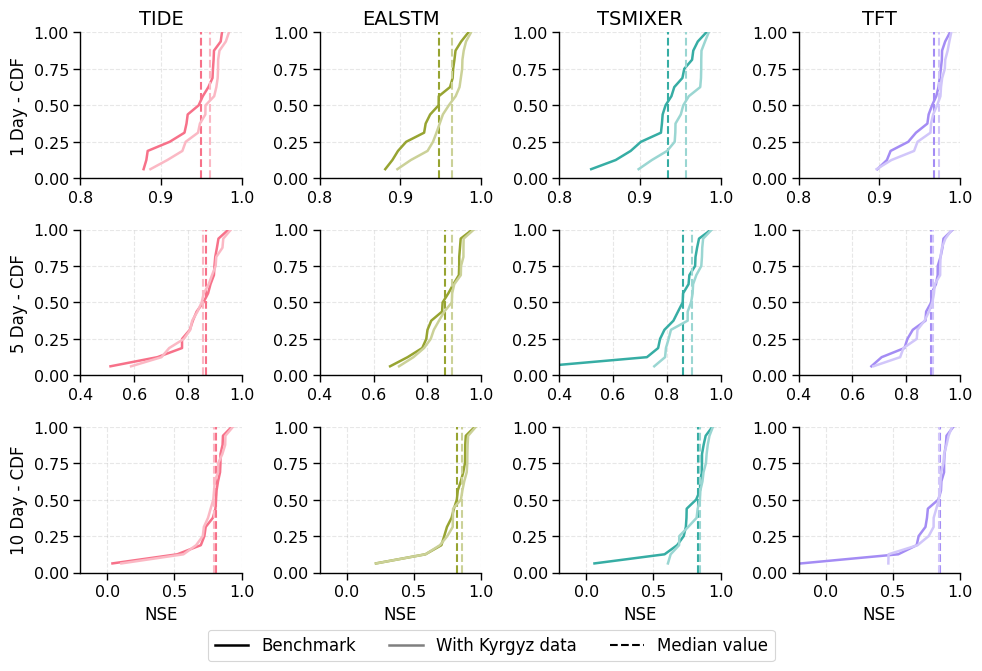

In [256]:
fig, axes = plot_model_cdf_grid(seasonal_results, palette=palette)
path_to_save = "/Users/cooper/Desktop/CAMELS-CH/images/DataSharing/cdf_grid_all_models_tajikistan.png"

plt.savefig(path_to_save, bbox_inches="tight", dpi=300)
plt.show()

---

In [227]:
from typing import Dict, Any, List, Tuple, Optional, Union
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import matplotlib.patches as mpatches


def get_average_nse(basin_id, horizon, seasonal_results):
    """
    Calculate average NSE values for benchmark and combined models.

    Args:
        basin_id (str): Basin identifier (e.g., "CA_17150")
        horizon (int): Forecast horizon (1-10)
        seasonal_results (dict): Dictionary containing model results

    Returns:
        tuple: (benchmark_nse, combined_nse)
    """
    NSE_values_benchmark = 0
    NSE_values_combined = 0
    benchmark_count = 0
    combined_count = 0

    for key in seasonal_results.keys():
        if key == "dummy":
            continue

        if key.endswith("_benchmark"):
            NSE_values_benchmark += seasonal_results[key]["basin_metrics"][basin_id][
                horizon
            ]["NSE"]
            benchmark_count += 1
        elif key.endswith("_combined"):
            NSE_values_combined += seasonal_results[key]["basin_metrics"][basin_id][
                horizon
            ]["NSE"]
            combined_count += 1

    benchmark_avg = NSE_values_benchmark / benchmark_count if benchmark_count > 0 else 0
    combined_avg = NSE_values_combined / combined_count if combined_count > 0 else 0

    return (benchmark_avg, combined_avg)


def plot_rolling_forecast_ensemble(
    evaluator_results: Dict[str, Dict[str, Any]],
    models_to_plot: List[str],
    horizon: int,
    group_identifier: str,
    palette: List[str],
    fig_size: tuple = (10, 6),
    title: str = None,
    start_year: Optional[int] = None,
    end_year: Optional[int] = None,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create a rolling forecast plot comparing model ensembles grouped by variant
    (benchmark vs combined) for a specific basin and horizon.

    Args:
        evaluator_results: Dictionary containing evaluation results for multiple models.
            Each model has keys including 'df' with prediction results.
        models_to_plot: List of model keys to include in the plot.
        horizon: Forecast horizon to visualize.
        group_identifier: Basin ID or group identifier to plot.
        palette: List of colors for model variants (benchmark/combined).
        fig_size: Figure size as (width, height).
        title: Custom title for the plot.
        start_year: Optional starting year to filter the data (inclusive).
        end_year: Optional ending year to filter the data (inclusive).

    Returns:
        Tuple containing the figure and axes objects.

    Raises:
        ValueError: If group_identifier is not found in results or models_to_plot contains invalid model keys.
    """

    benchmark_avg_nse, combined_avg_nse = get_average_nse(group_identifier, horizon, evaluator_results)

    # Validate models to plot
    for model in models_to_plot:
        if model not in evaluator_results:
            available_models = list(evaluator_results.keys())
            raise ValueError(
                f"Model '{model}' not found in evaluator_results. Available models: {available_models}"
            )

    # Create plot with Seaborn style
    fig, ax = plt.subplots(figsize=fig_size)

    # Group models by variant (benchmark vs combined)
    benchmark_models = [m for m in models_to_plot if "benchmark" in m and m != "dummy"]
    combined_models = [m for m in models_to_plot if "combined" in m]

    # Ensure we have at least one model in each group
    benchmark_exists = len(benchmark_models) > 0
    combined_exists = len(combined_models) > 0

    # Create dataframes to store prediction data for each group
    observed_df = None
    benchmark_dfs = []
    combined_dfs = []

    # Process each model's data
    for model in models_to_plot:
        # Get the DataFrame for this model
        df = evaluator_results[model]["df"]

        # Filter for the specific basin and horizon
        basin_df = df[
            (df["basin_id"] == group_identifier) & (df["horizon"] == horizon)
        ].copy()

        # Apply year filtering if specified
        if start_year is not None or end_year is not None:
            # Ensure date column is datetime type
            if not pd.api.types.is_datetime64_any_dtype(basin_df["date"]):
                basin_df["date"] = pd.to_datetime(basin_df["date"])

            # Apply start year filter
            if start_year is not None:
                start_date = datetime(start_year, 1, 1)
                basin_df = basin_df[basin_df["date"] >= start_date]

            # Apply end year filter
            if end_year is not None:
                end_date = datetime(end_year, 12, 31)
                basin_df = basin_df[basin_df["date"] <= end_date]

        if basin_df.empty:
            print(
                f"Warning: No data for model '{model}', basin '{group_identifier}', horizon {horizon}"
                + (
                    f", years {start_year}-{end_year}"
                    if start_year is not None or end_year is not None
                    else ""
                )
            )
            continue

        # Store observed data (same for all models)
        if observed_df is None:
            observed_df = basin_df[["date", "observed"]].copy()

        elif "benchmark" in model:
            benchmark_dfs.append(basin_df[["date", "prediction"]].copy())
        elif "combined" in model:
            combined_dfs.append(basin_df[["date", "prediction"]].copy())

    # Check if we have any data to display
    if observed_df is None or (not benchmark_exists and not combined_exists):
        available_ids = set()
        for model in models_to_plot:
            available_ids.update(evaluator_results[model]["df"]["basin_id"].unique())
        raise ValueError(
            f"Group identifier '{group_identifier}' not found in results. Available IDs: {available_ids}"
        )

    # Create a list to store legend handles
    legend_handles = []

    # Plot observed data
    observed_line = ax.plot(
        observed_df["date"],
        observed_df["observed"],
        color="black",
        label="Observed",
        linewidth=2,
    )[0]
    legend_handles.append(observed_line)

    # Process benchmark models ensemble
    if benchmark_exists and benchmark_dfs:
        # Create a merged dataframe with all benchmark predictions
        benchmark_merged = observed_df[["date"]].copy()
        for i, bdf in enumerate(benchmark_dfs):
            benchmark_merged = pd.merge(benchmark_merged, bdf, on="date", how="left")
            benchmark_merged = benchmark_merged.rename(
                columns={"prediction": f"pred_{i}"}
            )

        # Calculate statistics across benchmark models
        pred_cols = [col for col in benchmark_merged.columns if col.startswith("pred_")]
        benchmark_merged["mean"] = benchmark_merged[pred_cols].mean(axis=1)
        benchmark_merged["std"] = benchmark_merged[pred_cols].std(axis=1)

        # Plot benchmark ensemble
        benchmark_color = palette[0]
        benchmark_line = ax.plot(
            benchmark_merged["date"],
            benchmark_merged["mean"],
            color=benchmark_color,
            alpha=0.9,
            linestyle="-",
            label=f"Benchmark Ensemble (avg. NSE = {benchmark_avg_nse:.2f})",
            linewidth=2,
        )[0]
        legend_handles.append(benchmark_line)

        # Plot confidence interval (2-sigma = 95%)
        ax.fill_between(
            benchmark_merged["date"],
            benchmark_merged["mean"] - 2 * benchmark_merged["std"],
            benchmark_merged["mean"] + 2 * benchmark_merged["std"],
            color=benchmark_color,
            alpha=0.2,
        )

    # Process combined models ensemble
    if combined_exists and combined_dfs:
        # Create a merged dataframe with all combined predictions
        combined_merged = observed_df[["date"]].copy()
        for i, cdf in enumerate(combined_dfs):
            combined_merged = pd.merge(combined_merged, cdf, on="date", how="left")
            combined_merged = combined_merged.rename(
                columns={"prediction": f"pred_{i}"}
            )

        # Calculate statistics across combined models
        pred_cols = [col for col in combined_merged.columns if col.startswith("pred_")]
        combined_merged["mean"] = combined_merged[pred_cols].mean(axis=1)
        combined_merged["std"] = combined_merged[pred_cols].std(axis=1)

        # Plot combined ensemble
        combined_color = palette[1]
        combined_line = ax.plot(
            combined_merged["date"],
            combined_merged["mean"],
            color=combined_color,
            alpha=0.9,
            label=f"With Krygyz data Ensemble (avg. NSE = {combined_avg_nse:.2f})",
            linewidth=2,
        )[0]
        legend_handles.append(combined_line)

        # Plot confidence interval (2-sigma = 95%)
        ax.fill_between(
            combined_merged["date"],
            combined_merged["mean"] - 2 * combined_merged["std"],
            combined_merged["mean"] + 2 * combined_merged["std"],
            color=combined_color,
            alpha=0.2,
        )

    # Add a patch for the confidence interval to the legend
    confidence_patch = mpatches.Patch(
        color="gray", alpha=0.3, label="95% Confidence Interval"
    )
    legend_handles.append(confidence_patch)

    # Set title and labels
    if title is None:
        title = f"{horizon}-day Forecast Ensemble"

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("Streamflow [mm/d]", fontsize=12)

    # # Format x-axis to only show month names
    # ax.xaxis.set_major_formatter(
    #     mdates.DateFormatter("%b")
    # )  # %b gives abbreviated month names (Jan-Dec)
    # ax.xaxis.set_major_locator(mdates.MonthLocator())
    # Format x-axis to show year-month in numeric format
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))  
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 

    # Rotate tick labels for better readability
    plt.xticks(rotation=0)  # Horizontal labels are fine for short month names

    # Add custom legend with confidence interval patch
    ax.legend(handles=legend_handles, loc="upper right")

    ax.grid(True, alpha=0.7)
    sns.despine()
    plt.tight_layout()

    return fig, ax

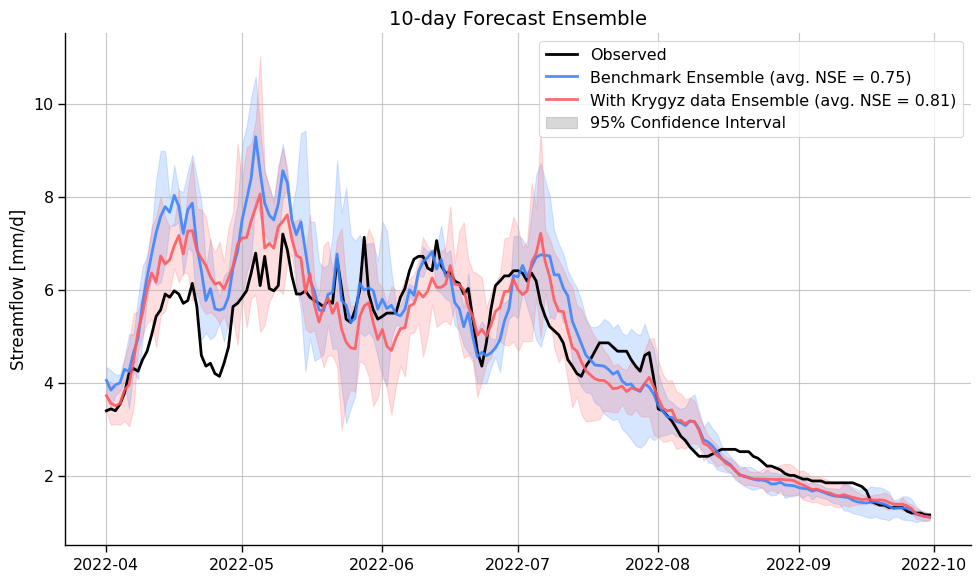

In [238]:
color_palette = ["#3A86FF", "#FF5A5F"]
basin_id = "CA_17150"
horizon = 10

fig, axes = plot_rolling_forecast_ensemble(
    seasonal_results,
    models_to_plot=[
        "tide_benchmark",
        "tide_combined",
        "ealstm_benchmark",
        "ealstm_combined",
        "tsmixer_benchmark",
        "tsmixer_combined",
        "tft_benchmark",
        "tft_combined",
    ],
    horizon=horizon,
    group_identifier=basin_id,
    palette=color_palette,
    start_year=2022,
    end_year=2022,
)

path_to_save = f"/Users/cooper/Desktop/CAMELS-CH/images/DataSharing/rolling_forecast_ensemble_id_{basin_id}_horizon_{horizon}.png"
fig.savefig(path_to_save, dpi=300, bbox_inches="tight")

plt.show()




---

# Performance table for LaTeX

In [ ]:
import numpy as np
import pandas as pd
from typing import Dict, List, Any, Tuple


def extract_metrics_statistics(
    seasonal_results: Dict[str, Dict[str, Dict[str, Dict[int, Dict[str, np.float32]]]]],
    model_ids: List[str],
    metrics: List[str],
) -> pd.DataFrame:
    """
    Extract median and standard deviation of metrics across all basins and lead times.

    Args:
        seasonal_results: Nested dictionary with model results
        model_ids: List of model identifiers to process
        metrics: List of metrics to extract

    Returns:
        DataFrame with median and std dev for each model and metric
    """
    results = []

    for model_id in model_ids:
        if model_id not in seasonal_results:
            continue

        # Get all basin results for this model
        basin_metrics = seasonal_results[model_id]["basin_metrics"]

        # Extract all values for each metric
        metric_values = {metric: [] for metric in metrics}

        # Loop through all basins and lead times
        for basin, lead_times in basin_metrics.items():
            for lead_time, metrics_dict in lead_times.items():
                for metric in metrics:
                    if metric in metrics_dict:
                        metric_values[metric].append(float(metrics_dict[metric]))

        # Calculate median and std dev for each metric
        model_stats = {}
        for metric in metrics:
            values = np.array(metric_values[metric])
            median = np.median(values)
            std_dev = np.std(values)
            model_stats[f"{metric}_median"] = median
            model_stats[f"{metric}_std"] = std_dev

        # Add model name
        model_stats["model_id"] = model_id
        results.append(model_stats)

    return pd.DataFrame(results)


def format_for_latex(
    df: pd.DataFrame, metrics: List[str], model_mapping: Dict[str, str]
) -> str:
    """
    Format the statistics dataframe for a LaTeX table.

    Args:
        df: DataFrame with metrics statistics
        metrics: List of metrics to include
        model_mapping: Dictionary mapping model IDs to display names

    Returns:
        Formatted string for LaTeX table rows
    """
    latex_rows = []

    for _, row in df.iterrows():
        model_id = row["model_id"]
        display_name = model_mapping.get(model_id, model_id)

        # Build row string
        metric_cells = []
        for metric in metrics:
            median = row[f"{metric}_median"]
            std = row[f"{metric}_std"]
            formatted_value = f"{median:.2f} $\\pm$ {std:.2f}"
            metric_cells.append(formatted_value)

        # Join cells with & and add line ending
        latex_row = display_name + " & " + " & ".join(metric_cells) + " \\\\"
        latex_rows.append(latex_row)

    return "\n".join(latex_rows)


# List of models and metrics
model_ids = [
    "tide_benchmark",
    "tide_combined",
    "ealstm_benchmark",
    "ealstm_combined",
    "tsmixer_benchmark",
    "tsmixer_combined",
    "tft_benchmark",
    "tft_combined",
]

metrics = ["NSE", "RMSE", "MAE", "MSE"]

# Model name mapping for display
model_mapping = {
    "tide_benchmark": "TiDE (Benchmark)",
    "tide_combined": "TiDE (Data Sharing)",
    "ealstm_benchmark": "EA-LSTM (Benchmark)",
    "ealstm_combined": "EA-LSTM (Data Sharing)",
    "tsmixer_benchmark": "TSMixer (Benchmark)",
    "tsmixer_combined": "TSMixer (Data Sharing)",
    "tft_benchmark": "TFT (Benchmark)",
    "tft_combined": "TFT (Data Sharing)",
}

# Extract statistics
metrics_df = extract_metrics_statistics(seasonal_results, model_ids, metrics)

# Sort to match the order in the table
sorted_df = pd.DataFrame(columns=metrics_df.columns)
for model_id in model_ids:
    model_row = metrics_df[metrics_df["model_id"] == model_id]
    if not model_row.empty:
        sorted_df = pd.concat([sorted_df, model_row], ignore_index=True)

# Format for LaTeX
latex_content = format_for_latex(sorted_df, metrics, model_mapping)

# Display the formatted content (which you would then paste into your LaTeX table)
print(latex_content)

# You can also generate the complete table if needed
complete_table = (
    r"""
\begin{table}[htbp]
\centering
\begin{tabular}{lcccc}
\toprule
{Model} & {NSE} & {RMSE} & {MAE} & {MSE} \\
\midrule
"""
    + latex_content
    + r"""
\bottomrule
\end{tabular}
\caption{Model performance metrics (median $\pm$ standard deviation) across basins and lead times.}
\label{tab:pivoted_metrics}
\end{table}
"""
)

print("\nComplete table:")
print(complete_table)

TiDE (Benchmark) & 0.86 $\pm$ 0.15 & 0.43 $\pm$ 0.51 & 0.28 $\pm$ 0.34 & 0.19 $\pm$ 1.31 \\
TiDE (Data Sharing) & 0.86 $\pm$ 0.14 & 0.39 $\pm$ 0.52 & 0.27 $\pm$ 0.32 & 0.16 $\pm$ 1.23 \\
EA-LSTM (Benchmark) & 0.88 $\pm$ 0.12 & 0.39 $\pm$ 0.45 & 0.27 $\pm$ 0.30 & 0.16 $\pm$ 0.97 \\
EA-LSTM (Data Sharing) & 0.90 $\pm$ 0.12 & 0.36 $\pm$ 0.44 & 0.25 $\pm$ 0.29 & 0.13 $\pm$ 0.94 \\
TSMixer (Benchmark) & 0.87 $\pm$ 0.14 & 0.42 $\pm$ 0.51 & 0.28 $\pm$ 0.34 & 0.17 $\pm$ 1.27 \\
TSMixer (Data Sharing) & 0.90 $\pm$ 0.08 & 0.37 $\pm$ 0.38 & 0.24 $\pm$ 0.25 & 0.14 $\pm$ 0.59 \\
TFT (Benchmark) & 0.89 $\pm$ 0.15 & 0.37 $\pm$ 0.48 & 0.24 $\pm$ 0.32 & 0.14 $\pm$ 1.22 \\
TFT (Data Sharing) & 0.90 $\pm$ 0.10 & 0.36 $\pm$ 0.39 & 0.23 $\pm$ 0.26 & 0.13 $\pm$ 0.68 \\

Complete table:

\begin{table}[htbp]
\centering
\begin{tabular}{lcccc}
\toprule
{Model} & {NSE} & {RMSE} & {MAE} & {MSE} \\
\midrule
TiDE (Benchmark) & 0.86 $\pm$ 0.15 & 0.43 $\pm$ 0.51 & 0.28 $\pm$ 0.34 & 0.19 $\pm$ 1.31 \\
TiDE (Data Shari

/var/folders/y6/kqwqph4s3sj7hkxryrly5y6r0000gn/T/ipykernel_17793/774722772.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sorted_df = pd.concat([sorted_df, model_row], ignore_index=True)
